In [4]:
import vesuvius
from vesuvius import Volume
import matplotlib.pyplot as plt
segment_id = 20230827161847
segment = Volume(segment_id, normalize=True)

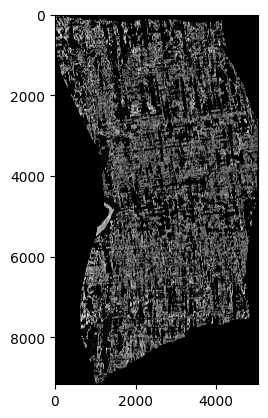

In [5]:
plt.imshow(segment[19,:,:], cmap='grey')

[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]


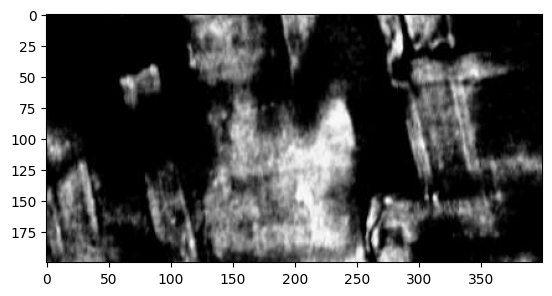

In [6]:
# plt.imshow(segment[28,0:400,0:1400], cmap='gray')
plt.imshow(segment[28,200:400,1000:1400], cmap='gray')
print(segment[28,200:232,1000:1032])

In [46]:
import zarr
import numpy as np
from tqdm import tqdm
import os
import json

class EfficientVolumeNormalizer:
    """
    Efficiently normalizes large Zarr volumes using mean and standard deviation.
    - Ignores black regions (pixels with value 0).
    - Handles chunks sequentially to avoid memory issues.
    """
    def __init__(self, zarr_path, mask, black_threshold=0):
        self.zarr_path = zarr_path
        self.volume = zarr.open(zarr_path, mode='r')
        self.mask = mask
        self.black_threshold = black_threshold
        self.global_mean = None
        self.global_std = None
        self.cache_path = "./normalization_cache.json"

    def _load_cache(self):
        """Load normalization cache from file."""
        if not os.path.exists(self.cache_path):
            return {}
        with open(self.cache_path, "r") as f:
            return json.load(f)

    def _update_cache(self, segment_id, mean, std):
        """Update normalization cache with new values."""
        cache = self._load_cache()
        cache[segment_id] = {"mean": mean, "std": std}
        with open(self.cache_path, "w") as f:
            json.dump(cache, f)

    def compute_global_stats(self, segment_id, start_level=0, end_level=None, chunk_size=1024):
        """Compute global mean and std using the mask."""
        cache = self._load_cache()
        if segment_id in cache:
            print(f"[INFO] Using cached normalization for segment {segment_id}")
            self.global_mean = cache[segment_id]["mean"]
            self.global_std = cache[segment_id]["std"]
            return

        if end_level is None:
            end_level = self.volume.shape[0]
        
        total_sum = 0.0  # Use float64 for precision
        total_squared_sum = 0.0  # Use float64 for precision
        total_count = 0
        
        # Debug counters
        chunks_processed = 0
        chunks_skipped = 0
        
        # Iterate through larger chunks
        for z in tqdm(range(start_level, end_level)):
            for y in range(0, self.volume.shape[1], chunk_size):
                for x in range(0, self.volume.shape[2], chunk_size):
                    chunk = self.volume[z, y:y+chunk_size, x:x+chunk_size]
                    mask_chunk = self.mask[y:y+chunk_size, x:x+chunk_size]
                    valid_pixels = chunk[mask_chunk > 0]
                    
                    # Debug: Print chunk statistics for first few chunks
                    if chunks_processed < 5:
                        print(f"Processing chunk at depth {z}, y={y}, x={x}")
                        print(f"  Chunk shape: {chunk.shape}")
                        print(f"  Chunk min/max: {chunk.min()}/{chunk.max()}")
                        print(f"  Valid pixels count: {valid_pixels.size} out of {chunk.size}")
                        if valid_pixels.size > 0:
                            print(f"  Valid pixels min/max: {valid_pixels.min()}/{valid_pixels.max()}")
                            print(f"  Valid pixels mean: {valid_pixels.mean():.2f}")
                            print(f"  Valid pixels std: {valid_pixels.std():.2f}")
                        print()
                    
                    # Skip if no valid pixels
                    if valid_pixels.size == 0:
                        chunks_skipped += 1
                        continue
                    
                    # Update global statistics
                    chunk_sum = np.sum(valid_pixels, dtype=np.float64)
                    chunk_squared_sum = np.sum(valid_pixels.astype(np.float64) ** 2, dtype=np.float64)
                    
                    total_sum += chunk_sum
                    total_squared_sum += chunk_squared_sum
                    total_count += valid_pixels.size
                    
                    chunks_processed += 1
                    
                    # Debug: Print intermediate totals for first few chunks
                    if chunks_processed <= 5:
                        print(f"  Chunk sum: {chunk_sum:.2f}")
                        print(f"  Chunk squared sum: {chunk_squared_sum:.2f}")
                        print(f"  Running total_sum: {total_sum:.2f}")
                        print(f"  Running total_squared_sum: {total_squared_sum:.2f}")
                        print(f"  Running total_count: {total_count}")
                        print(f"  Running mean so far: {total_sum / total_count:.2f}")
                        print("  " + "="*50)
        
        print(f"Chunks processed: {chunks_processed}, Chunks skipped: {chunks_skipped}")
        
        if total_count == 0:
            raise ValueError("No valid pixels found in the dataset.")
        
        # Compute global mean
        self.global_mean = total_sum / total_count
        
        # Compute global variance (numerically stable)
        mean_of_squares = total_squared_sum / total_count
        square_of_mean = self.global_mean ** 2
        variance = mean_of_squares - square_of_mean
        
        # Debug variance calculation
        print(f"Variance calculation debug:")
        print(f"  mean_of_squares: {mean_of_squares:.6f}")
        print(f"  square_of_mean: {square_of_mean:.6f}")
        print(f"  variance: {variance:.6f}")
        
        if variance < 0:
            print(f"WARNING: Negative variance detected ({variance}), setting to 0")
            variance = 0
        
        self.global_std = np.sqrt(variance)
        
        # Final statistics
        print(f"Final Statistics:")
        print(f"  Total sum: {total_sum:.2f}")
        print(f"  Total squared sum: {total_squared_sum:.2f}")
        print(f"  Total count: {total_count}")
        print(f"  Global Mean: {self.global_mean:.6f}")
        print(f"  Global Std: {self.global_std:.6f}")
        
        # Sanity check
        if self.global_std == 0:
            print("ERROR: Standard deviation is 0!")
            print("This suggests all valid pixels have the same value.")
            print("Check your data and black_threshold setting.")

    def normalize_chunk(self, chunk):
        """
        Normalize a smaller chunk (e.g., 8x32x32) using global mean and std.
        """
        if self.global_mean is None or self.global_std is None:
            raise ValueError("Global statistics not computed. Call compute_global_stats() first.")
        
        if self.global_std == 0:
            print("WARNING: Cannot normalize with std=0, returning original chunk")
            return chunk.astype(np.float32)
        
        # Create mask for black pixels
        black_mask = chunk <= self.black_threshold
        
        # Normalize non-black pixels
        normalized = (chunk.astype(np.float32) - self.global_mean) / self.global_std
        
        # Set black pixels to 0
        normalized[black_mask] = 0.0
        
        return normalized

    def create_normalized_chunks(self, start_level, end_level, chunk_size=(8, 32, 32)):
        """
        Generator that yields normalized smaller chunks (e.g., 8x32x32).
        """
        if self.global_mean is None or self.global_std is None:
            raise ValueError("Global statistics not computed. Call compute_global_stats() first.")
        
        for z in range(start_level, end_level):
            depth, height, width = self.volume.shape
            for y in range(0, height, chunk_size[1]):
                for x in range(0, width, chunk_size[2]):
                    # Extract smaller chunk
                    chunk = self.volume[z, y:y+chunk_size[1], x:x+chunk_size[2]]
                    
                    # Skip entirely black chunks
                    if np.all(chunk <= self.black_threshold):
                        continue
                    
                    # Normalize chunk
                    yield self.normalize_chunk(chunk)

Computing global statistics...


  0%|          | 0/21 [00:00<?, ?it/s]

Processing chunk at depth 0, y=0, x=0
  Chunk shape: (1024, 1024)
  Chunk min/max: 0/65535
  Valid pixels count: 936385 out of 1048576
  Valid pixels min/max: 0/65535
  Valid pixels mean: 32863.98
  Valid pixels std: 14057.58

  Chunk sum: 30773340120.00
  Chunk squared sum: 1196378822208790.00
  Running total_sum: 30773340120.00
  Running total_squared_sum: 1196378822208790.00
  Running total_count: 936385
  Running mean so far: 32863.98
Processing chunk at depth 0, y=0, x=1024
  Chunk shape: (1024, 1024)
  Chunk min/max: 0/65535
  Valid pixels count: 871465 out of 1048576
  Valid pixels min/max: 0/65535
  Valid pixels mean: 28904.72
  Valid pixels std: 12215.59

  Chunk sum: 25189451611.00
  Chunk squared sum: 858134549816195.00
  Running total_sum: 55962791731.00
  Running total_squared_sum: 2054513372024985.00
  Running total_count: 1807850
  Running mean so far: 30955.44
Processing chunk at depth 0, y=0, x=2048
  Chunk shape: (1024, 1024)
  Chunk min/max: 0/65535
  Valid pixels co

100%|██████████| 21/21 [00:33<00:00,  1.59s/it]



Chunks processed: 882, Chunks skipped: 63
Variance calculation debug:
  mean_of_squares: 1096613906.296116
  square_of_mean: 969906049.495988
  variance: 126707856.800128
Final Statistics:
  Total sum: 21423158605622.00
  Total squared sum: 754349171956031616.00
  Total count: 687889482
  Global Mean: 31143.314684
  Global Std: 11256.458448
Time taken to compute global stats: 33.38 seconds



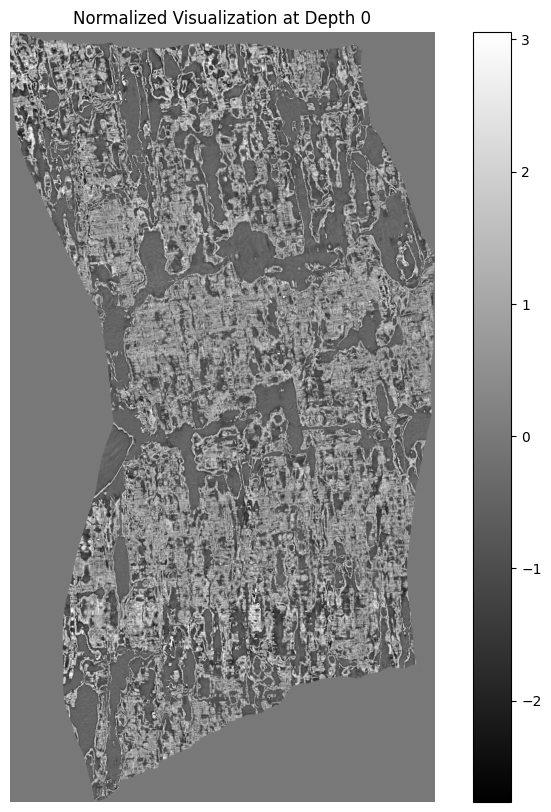

In [47]:
import cv2
# Configuration
zarr_path = "/media/jeff/Seagate/vesuvius-3dstreamer/20230827161847_singlethreaded.zarr"
start_level = 0
end_level = 21
visualization_depth = 0  # Specify the depth to visualize

# retrieve the mask by reading /media/jeff/Seagate/vesuvius/masks/20230827161847.png and dividing by 255.0
mask = cv2.imread("/media/jeff/Seagate/vesuvius/masks/20230827161847.png", cv2.IMREAD_GRAYSCALE) / 255.0

# Initialize normalizer
normalizer = EfficientVolumeNormalizer(zarr_path, mask, black_threshold=0)

# Compute global statistics
print("Computing global statistics...")
import time
start_time = time.time()
normalizer.compute_global_stats(20230827161847, start_level, end_level, 1024)
time1 = time.time() - start_time
print(f"Time taken to compute global stats: {time1:.2f} seconds\n")

# Load the volume
volume = zarr.open(zarr_path, mode='r')

# Extract the specified depth slice
depth_slice = volume[visualization_depth, :, :]

# Normalize the depth slice
normalized_slice = normalizer.normalize_chunk(depth_slice)

# Visualize the normalized slice
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))
plt.imshow(normalized_slice, cmap='gray')
plt.colorbar()
plt.title(f"Normalized Visualization at Depth {visualization_depth}")
plt.axis('off')
plt.show()

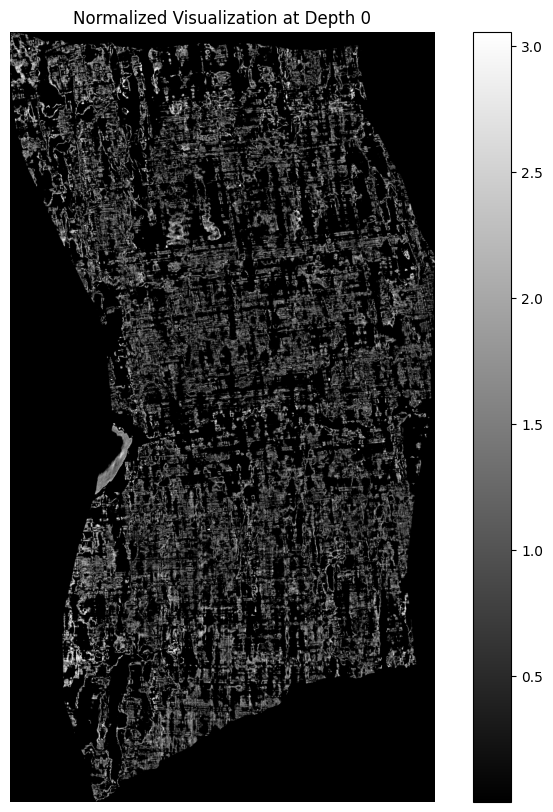

In [50]:
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import numpy as np

# Create a custom colormap
cmap = plt.cm.gray.copy()
cmap.set_under('black')  # Set values below vmin to black

plt.figure(figsize=(10, 10))
depth_slice = volume[19, :, :]
normalized_slice = normalizer.normalize_chunk(depth_slice)
plt.imshow(normalized_slice, cmap=cmap, vmin=0.001)  # vmin slightly above 0
plt.colorbar()
plt.title(f"Normalized Visualization at Depth {visualization_depth}")
plt.axis('off')
plt.show()

In [23]:
# Configuration
zarr_path = "/media/jeff/Seagate/vesuvius-3dstreamer/20230827161847_singlethreaded.zarr"
start_level = 0
end_level = 21

# Load the volume
volume = zarr.open(zarr_path, mode='r')

# Iterate through each depth
for z in range(start_level, end_level):
    depth_slice = volume[z, :, :]
    
    # Flatten the slice and filter out black pixels (value == 0)
    valid_pixels = depth_slice[depth_slice > 0]
    
    if valid_pixels.size == 0:
        print(f"Depth {z}: No valid pixels (all black).")
        continue
    
    # Calculate statistics
    mean = np.mean(valid_pixels)
    std = np.std(valid_pixels)
    min_val = np.min(valid_pixels)
    max_val = np.max(valid_pixels)
    
    print(f"Depth {z}: Mean={mean:.2f}, Std={std:.2f}, Min={min_val}, Max={max_val}")

    # Check for any values at 1 or 65535
    one_locations = np.argwhere(depth_slice == 1)
    max_locations = np.argwhere(depth_slice == 65535)

    if one_locations.size > 0:
        print(f"Depth {z}: Found {len(one_locations)} pixels at 1.")
        print(f"Sample locations (up to 5): {one_locations[:5]}")
    
    if max_locations.size > 0:
        print(f"Depth {z}: Found {len(max_locations)} pixels at 65535.")
        print(f"Sample locations (up to 5): {max_locations[:5]}")

Depth 0: Mean=31622.51, Std=11157.75, Min=1, Max=65535
Depth 0: Found 16 pixels at 1.
Sample locations (up to 5): [[ 514  212]
 [ 523  213]
 [ 526  212]
 [ 553  229]
 [ 595 1393]]
Depth 0: Found 21351 pixels at 65535.
Sample locations (up to 5): [[13 56]
 [13 57]
 [14 55]
 [14 56]
 [14 57]]
Depth 1: Mean=31667.71, Std=11161.23, Min=1, Max=65535
Depth 1: Found 15 pixels at 1.
Sample locations (up to 5): [[ 592  318]
 [ 746  947]
 [1398  870]
 [1514  545]
 [2277  939]]
Depth 1: Found 20911 pixels at 65535.
Sample locations (up to 5): [[14 58]
 [15 57]
 [15 58]
 [16 58]
 [38 60]]
Depth 2: Mean=31698.73, Std=11163.84, Min=1, Max=65535
Depth 2: Found 11 pixels at 1.
Sample locations (up to 5): [[ 524  218]
 [ 529  217]
 [ 585  297]
 [1644  844]
 [2185  922]]
Depth 2: Found 21469 pixels at 65535.
Sample locations (up to 5): [[ 52  52]
 [ 62 270]
 [ 62 271]
 [ 63 270]
 [ 63 271]]
Depth 3: Mean=31703.86, Std=11160.18, Min=1, Max=65535
Depth 3: Found 19 pixels at 1.
Sample locations (up to 5): 

In [21]:
normalized_slice.mean(), normalized_slice.std()

(np.float32(0.3417065), np.float32(0.26200306))

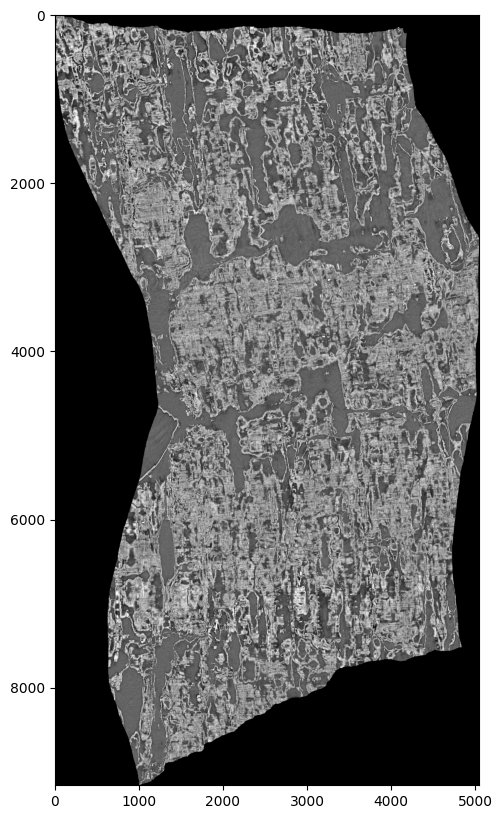

In [5]:
plt.figure(figsize=(10, 10))
plt.imshow(assembled_image[0], cmap='grey')

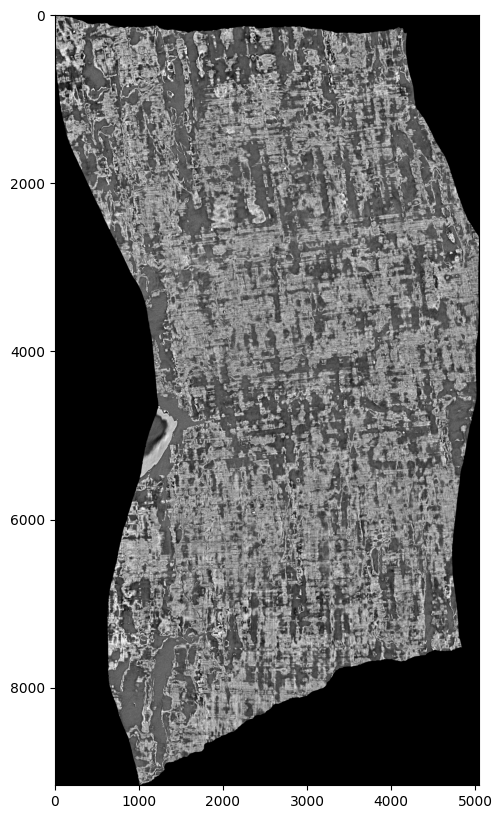

In [6]:
plt.figure(figsize=(10, 10))
plt.imshow(assembled_image[19], cmap='grey')

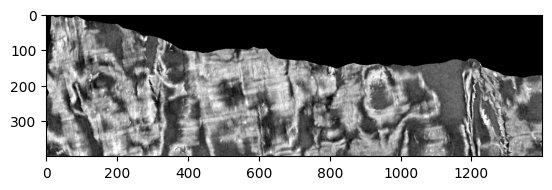

In [7]:
plt.imshow(assembled_image[0, 0:400, 0:1400]/65535, cmap='gray')

0.0
1.0


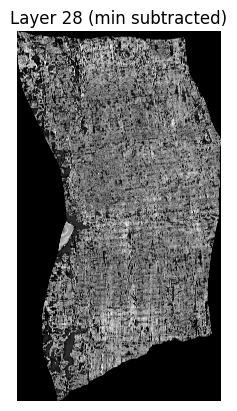

In [8]:
import tifffile

tif_path = "/media/jeff/Seagate/phalanx/data/scroll1/fragments/20230827161847/layers/28.tif"
tif_image = tifffile.imread(tif_path)/65535
print(tif_image.min())
print(tif_image.max())

# subtract 0.25, clip to 0 where necessary

tif_image_adj = tif_image - 0.265
tif_image_adj = tif_image_adj.clip(min=0)

plt.imshow(tif_image_adj, cmap='gray')
plt.title("Layer 28 (min subtracted)")
plt.axis('off')
plt.show()

